# astero_solver examples

A back-of-envelope calculator for asteroseismic scaling relations: give it any subset of a star's
observed parameters (with uncertainties), and it returns any other parameter(s) you ask for --
marginalizing over whatever wasn't given, using nested sampling (or, when everything given is exact,
skipping the sampler entirely for a fast point estimate).

See `README.md` in the package for the full API reference and caveats -- this notebook is a tour of
the main use cases.

In [1]:
import asteroscale as ast
from asteroscale import relations

## 1. Basic usage: fully constrained star

Give mass, radius, Teff, and [Fe/H] with uncertainties; ask for numax and dnu. This is the simplest
case -- every fundamental parameter is directly constrained, so there's not much to marginalize
over.

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
numax             3099       207.9        2887        3093        3300
dnu              135.3       5.476       129.7       135.2       140.6


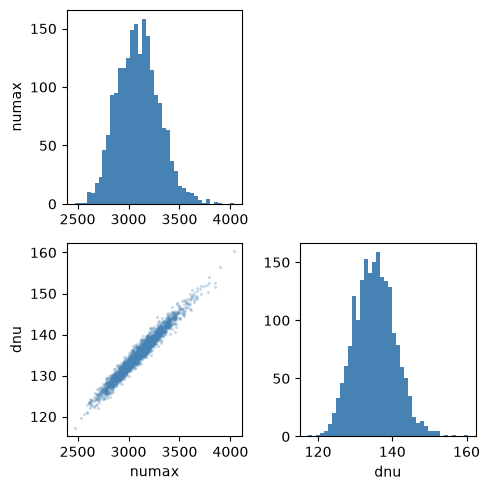

In [2]:
solver = ast.Solver(seed=0)

given = {"M": (1.0, 0.05), "R": (1.0, 0.02), "Teff": (5777, 50), "FeH": (0.0, 0.05)}
out = solver.solve(given, want=["numax", "dnu"])
ast.summarize(out)
fig = ast.plot_posterior(out)

## 2. Marginalizing over an unconstrained parameter

Leave radius out entirely. `solve()` marginalizes over it using its default prior (log-uniform) --
there's no separate "inverse" relation needed, the same forward model handles every direction.

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
R                    1     0.02535      0.9743       1.002       1.026
dnu              135.2       1.966       133.2         135       137.2
rho              1.002     0.02944      0.9727      0.9992       1.031


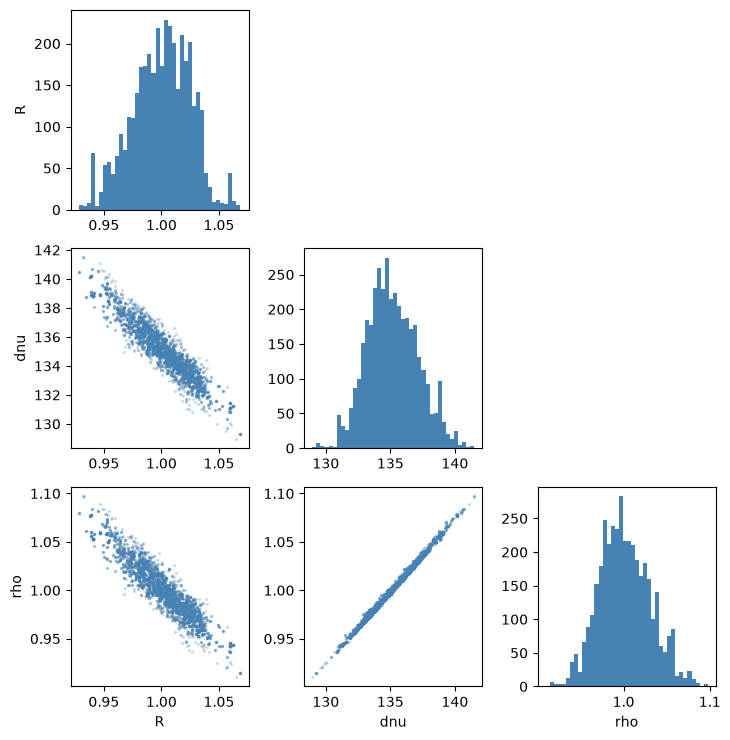

In [3]:
given = {"M": (1.0, 0.05), "Teff": (5777, 50), "FeH": (0.0, 0.05), "numax": (3090, 30)}
out = solver.solve(given, want=["R", "dnu", "rho"])
ast.summarize(out)
fig = ast.plot_posterior(out)

## 3. Combining seismology with Gaia astrometry and photometry

numax and dnu alone leave a mass-radius degeneracy (for a given Teff). Adding parallax and an
apparent Gaia G magnitude breaks it, since they constrain radius/luminosity independently through
the distance modulus.

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
M               0.9963     0.03764      0.9592      0.9936       1.032
R               0.9981     0.01603      0.9821      0.9973       1.015
L               0.9966     0.04521      0.9511      0.9928       1.044


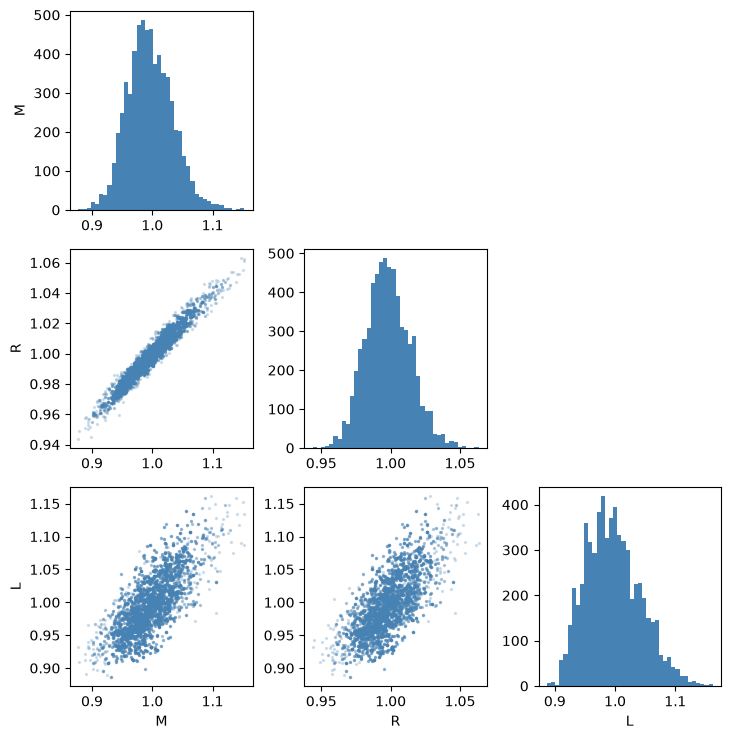

In [4]:
given = {
    "Teff": (5777, 50),
    "FeH": (0.0, 0.05),
    "numax": (3090, 30),
    "dnu": (135.1, 1.0),
    "plx": (10.0, 0.1),   # mas -> ~100 pc
    "G_mag": (9.90, 0.02),
}
out = solver.solve(given, want=["M", "R", "L"])
ast.summarize(out)
fig = ast.plot_posterior(out)

## 4. The top-level `solve()` shortcut

For one-off calculations, skip instantiating `Solver` yourself. This reuses a shared default solver
under the hood (unless you pass a `Solver` constructor argument like `num_warmup`/`priors`/`seed`,
which creates a fresh one).

In [5]:
out = ast.solve(given, want=["L", "R"])
ast.summarize(out)

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
L               0.9966     0.04603       0.953       0.992       1.038
R               0.9981     0.01627      0.9821      0.9975       1.014


## 5. Gaia BP-RP color as a parallax-free constraint

Unlike `G_mag`, the BP-RP color is (mostly) distance-independent -- the distance modulus cancels
between the two bands -- so it constrains Teff/extinction without needing a parallax at all. Note it's
degenerate with extinction on its own (see the README caveats): a single color can't separate Teff
from reddening without an informative `A_G` prior.

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
Teff              5710       48.05        5666        5709        5757
M               0.9855     0.04274      0.9417      0.9851       1.028
R               0.9956     0.01825      0.9767      0.9955       1.014


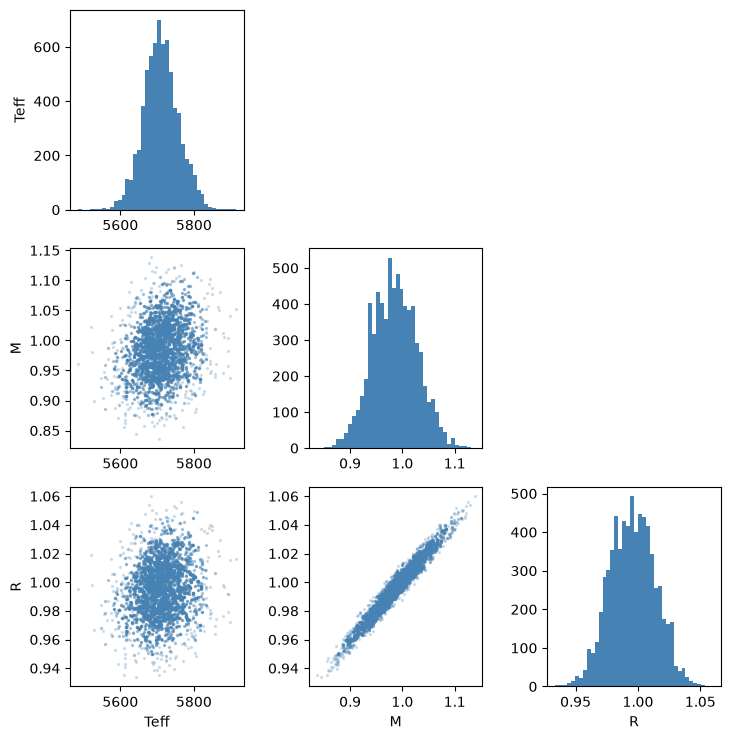

In [6]:
given = {
    "FeH": (0.0, 0.05),
    "numax": (3090, 30),
    "dnu": (135.1, 1.0),
    "BP_RP": (0.82, 0.02),
    "A_G": (0.05, 0.02),  # even a loose extinction estimate (e.g. from a dust map)
                            # breaks the reddening-Teff degeneracy and speeds this up a lot
}
out = ast.solve(given, want=["Teff", "M", "R"])
ast.summarize(out)
fig = ast.plot_posterior(out)

## 6. Metallicity corrections

`numax` and `dnu` both carry metallicity-dependent corrections (Viani et al. 2017 and
Guggenberger et al. 2016 respectively) -- small near solar composition, growing for metal-poor
stars.

In [7]:
print("f_numax([Fe/H]=0.0): ", relations.f_numax(0.0))
print("f_numax([Fe/H]=-2.0):", relations.f_numax(-2.0))
print()
print("dnu_ref(Teff=4800, [Fe/H]=0.0): ", relations.dnu_ref(4800, 0.0))
print("dnu_ref(Teff=4800, [Fe/H]=-2.0):", relations.dnu_ref(4800, -2.0))

f_numax([Fe/H]=0.0):  1.0
f_numax([Fe/H]=-2.0): 0.9816018911061287

dnu_ref(Teff=4800, [Fe/H]=0.0):  131.137855540754
dnu_ref(Teff=4800, [Fe/H]=-2.0): 129.13817266235347


## 7. Flexible input types

Each value in `given` can be:

- **a plain number** -- treated as exactly known (see the fast point-estimate path below)
- **a `(mean, error)` tuple** -- wrapped as a Gaussian
- **any object with `.log_prob`/`.logpdf`** -- used directly, e.g. for asymmetric uncertainty. This
  has to be JAX-differentiable (a `numpyro.distributions.Distribution`, or one of `priors.py`'s
  classes) since NUTS needs the gradient of the log-density -- a plain `scipy.stats` object won't
  work here (it's fine for the point-estimate path, which doesn't need gradients, just not for
  sampling).

Here's a right-skewed Teff measurement (say, from an asymmetric spectroscopic fit) supplied directly
as a `numpyro.distributions.Gumbel` (numpyro doesn't have a built-in skew-normal, but Gumbel gives
the same "asymmetric custom distribution" idea), mixed with ordinary Gaussian constraints on the rest.

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
Teff              5749       39.61        5711        5750        5791
M               0.9936      0.0415      0.9528      0.9944       1.032


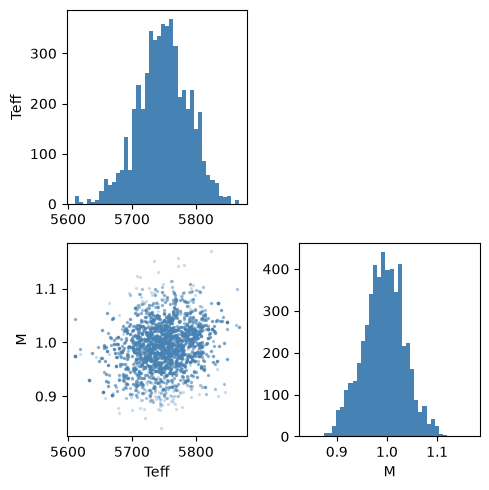

In [8]:
import scipy.stats as st
given = {
    "Teff": st.norm(loc=5750, scale=40),
    "FeH": (0.0, 0.05),
    "numax": (3090, 30),
    "dnu": (135.1, 1.0),
}
out = solver.solve(given, want=["Teff", "M"])
ast.summarize(out)
fig = ast.plot_posterior(out)

## 8. Fast point estimates (no sampler)

If *every* given value is a plain scalar (no uncertainty), `solve()` skips NUTS entirely: a direct
forward evaluation if every fundamental is pinned, or a single `scipy.optimize.least_squares`
call if you've given exact derived-quantity targets (like numax/dnu) instead. Either way this is
near-instant -- useful for tables of point estimates, or a quick sanity check before committing to a
full run.

In [9]:
import time

# every fundamental pinned -> direct forward evaluation
t0 = time.time()
out = solver.solve(
    {"M": 1.0, "R": 1.0, "Teff": 5772.0, "plx": 10.0, "A_G": 0.0, "FeH": 0.0},
    want=["numax", "dnu", "G_mag"],
)
print(out, f"({time.time()-t0:.4f}s)")

# exact derived targets instead -> least-squares solves for M, R
t0 = time.time()
out = solver.solve(
    {"Teff": 5772.0, "FeH": 0.0, "plx": 10.0, "A_G": 0.0, "numax": 3090.0, "dnu": 135.1},
    want=["M", "R"],
)
print(out, f"({time.time()-t0:.4f}s)")

{'numax': np.float64(3090.0), 'dnu': np.float64(135.1), 'G_mag': np.float64(9.808)} (0.0003s)
{'M': np.float64(0.9999999999999997), 'R': np.float64(0.9999999999999999)} (0.0234s)


Mutually inconsistent exact constraints get flagged rather than silently returning a bad fit --
here dnu=500 muHz is nowhere near consistent with numax=3090 muHz at solar Teff, so the least-squares
solve can't satisfy both and warns about it.

In [10]:
out = solver.solve(
    {"Teff": 5777.0, "FeH": 0.0, "plx": 10.0, "A_G": 0.0, "numax": 3090.0, "dnu": 500.0},
    want=["M", "R"],
)
print(out)

{'M': np.float64(0.5000000000000169), 'R': np.float64(0.7054485346074854)}


/tmp/ipykernel_125032/320219104.py:1: UserWarning: given['dnu'] = 500.0 is well outside the range this package is typically used/calibrated for (0.1 to 300.0). Double check units and value -- if this is intentional, the result may still be informative but treat it cautiously.
  out = solver.solve(
/home/ADF/nielsemb/work/repos/AsteroScale/asteroscale/solver.py:219: UserWarning: Point estimate did not fully satisfy the given constraints (largest residual 338.8). The given values may be physically inconsistent with each other, or the free parameters couldn't reach a solution within their prior bounds. Targets were: numax: target=3090, dnu: target=500.
  return self._point_estimate(fixed, want)


## 9. Custom priors

Override any fundamental parameter's prior: a `(mean, error)` tuple is shorthand for a Gaussian
(same convention as `given`), or pass a distribution directly for something else -- one of
`priors.py`'s classes, or a real `numpyro.distributions.Distribution` (e.g.
`numpyro.distributions.Uniform(low, high)` for a uniform prior specifically). As with `given`, this
has to be JAX-differentiable for the sampling path, not a plain `scipy.stats` object.

**Watch out:** if you use a `numpyro.distributions.Distribution` directly for M, R, Teff, or plx,
make sure it has bounded, strictly-positive support (e.g. `TruncatedNormal` with a positive `low`,
not a plain `Normal`) -- these parameters are physically positive-only, and relations like
`logg = log10(M/R^2)` aren't defined for non-positive inputs. An unbounded prior lets NUTS propose
a non-positive value during exploration, which doesn't cleanly error -- it produces a NaN gradient
that can make the sampler hang instead.

In [13]:
from asteroscale.distributions import TruncatedNormal

solver_custom = ast.Solver(
    priors={
        "Teff": (5750, 200),         # tuple shorthand -> Gaussian(5750, 200)
        "M": TruncatedNormal(loc=1.0, scale=0.1, low=0.1, high=3),  # a good mass
                                      # estimate -- bounded below at 0.1, not a
                                      # plain Normal (see the note above)
    },
    seed=0,
)
out = solver_custom.solve({"numax": (3090, 30), "dnu": (135.1, 1.0), "FeH": (0.0, 0.05)}, want=["Teff", "M", "R"])
ast.summarize(out)

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
Teff              5761       177.2        5586        5761        5942
M                0.992     0.04906      0.9417      0.9933       1.042
R               0.9959     0.01873      0.9771      0.9959       1.015


## 10. Retrieving more quantities after the fact with `predict()`

`solve()` only returns what you asked for in `want`, but the full forward pass (all derived
quantities -- luminosity, density, envelope FWHM, oscillation amplitude, Gaia photometry, ...) is
computed every time regardless. `predict()` re-reads it from the *last* `solve()` call without
re-running the sampler, for both the nested-sampling and point-estimate paths.

In [14]:
solver.solve(
    {"Teff": (5777, 50), "numax": (3090, 30), "dnu": (135.1, 1.0), "FeH": (0.0, 0.05)},
    want=["M", "R"],
)
extra = solver.predict(["L", "rho", "logg", "A_env", "FWHM_env"])
ast.summarize(extra)

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
L                1.003     0.05613      0.9473       1.002       1.062
rho              1.002     0.01459      0.9882       1.002       1.017
logg             4.438    0.004892       4.433       4.438       4.443
A_env            1.935     0.02463       1.911       1.934       1.959
FWHM_env         788.6       16.47       773.8       784.5       805.2


## 11. Input validation

Obvious mistakes are caught before anything expensive runs: unknown quantity names, malformed
`(mean, error)` pairs, non-positive errors, and physically impossible values (negative mass, radius,
Teff, parallax, or extinction) all raise immediately.

In [15]:
try:
    solver.solve({"M": -1.0, "Teff": 5772.0, "R": 1.0}, want=["numax"])
except ValueError as e:
    print("caught:", e)

try:
    solver.solve({"Teff": (5777, 50)}, want=["not_a_real_quantity"])
except KeyError as e:
    print("caught:", e)

caught: given['M'] = -1.0 is not physically valid -- M must be strictly positive.
caught: "Unknown quantity name(s) in want: ['not_a_real_quantity']. Valid names are: ['A_BP', 'A_G', 'A_RP', 'A_env', 'A_gran', 'BC_BP', 'BC_G', 'BC_RP', 'BP_RP', 'BP_mag', 'FWHM_env', 'FeH', 'G_mag', 'L', 'M', 'M_BP', 'M_G', 'M_RP', 'Mbol', 'R', 'RP_mag', 'Teff', 'b_gran_high', 'b_gran_low', 'd', 'dnu', 'logg', 'numax', 'plx', 'rho']"


Values that are merely unusual (rather than impossible) warn instead of erroring -- might be
exactly what you intend, but it's also the classic wrong-units typo.

In [16]:
import warnings

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    solver.solve({"Teff": 50000.0, "M": 1.0, "R": 1.0}, want=["numax"])
    for warning in w:
        print(warning.category.__name__, "-", warning.message)

ValueError: Not enough information for a point estimate: ['plx', 'A_G', 'FeH'] are unconstrained and no derived-quantity targets were given. Either fix all of M/R/Teff/plx/A_G/FeH, or give at least as many derived-quantity targets as free parameters.

## 12. Solving many targets in parallel

Each target is a completely independent problem -- `solve_many` just parallelizes the loop across
processes (one process per target, up to `n_jobs` at a time), it doesn't let targets share information
with each other. A target that fails (bad input, non-convergence, etc.) gets `{"_error": ...}` instead
of aborting the whole batch.

In [17]:
targets = {
    "star_A": {"Teff": (5777, 50), "FeH": (0.0, 0.05), "numax": (3090, 30), "dnu": (135.1, 1.0)},
    "star_B": {"Teff": (5000, 60), "FeH": (-0.2, 0.05), "numax": (150, 5), "dnu": (12.5, 0.3)},
    "star_C": {"Teff": (6200, 60), "FeH": (0.1, 0.05), "numax": (1800, 50), "dnu": (85.0, 1.5)},
}

results = ast.solve_many(targets, want=["M", "R"], show_progress=True)

for target_id, out in results.items():
    if "_error" in out:
        print(f"{target_id}: FAILED -- {out['_error']}")
    else:
        print(f"{target_id}: M = {out['M'].mean():.2f} +/- {out['M'].std():.2f}, "
              f"R = {out['R'].mean():.2f} +/- {out['R'].std():.2f}")

3/3 targets done
star_A: M = 1.00 +/- 0.04, R = 1.00 +/- 0.02
star_B: M = 1.16 +/- 0.17, R = 5.06 +/- 0.31
star_C: M = 1.25 +/- 0.14, R = 1.44 +/- 0.06
